In [ ]:
# 이제 여기에서 final_merged를 불러와서 작업을 시작하려고 합니다.

### 행 기준

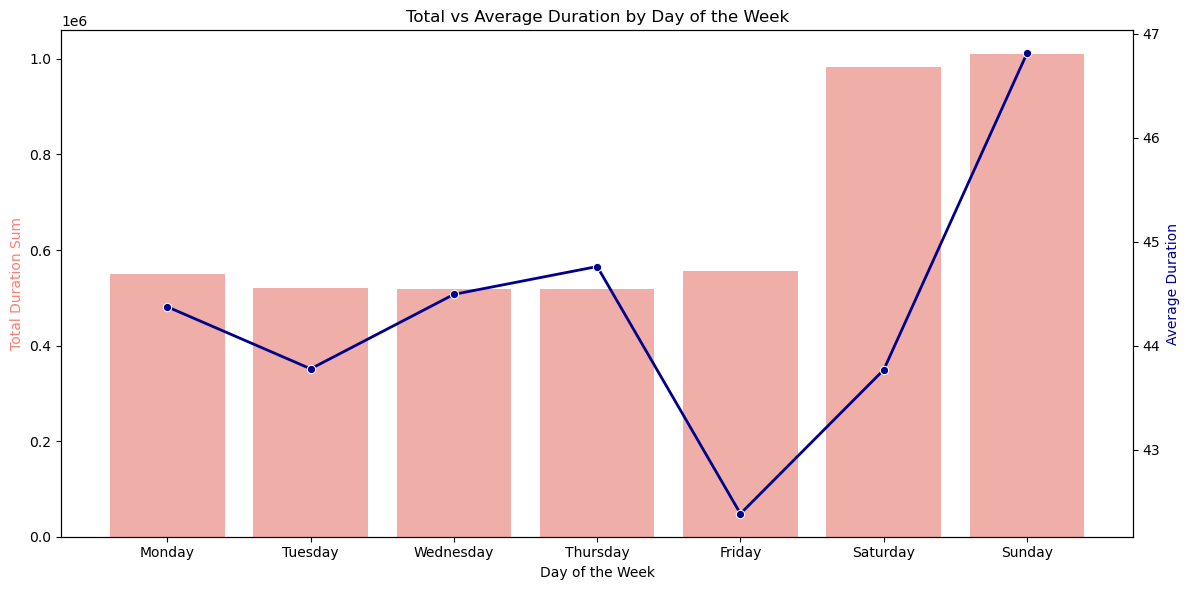

In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 파일 불러오기
file_path = r"C:\Users\user\Desktop\기업 연계 데이터\data merge\final_merged.csv"
df = pd.read_csv(file_path)

# WATCH_DAY 날짜형 변환
df["WATCH_DAY"] = pd.to_datetime(df["WATCH_DAY"].astype(str), format="%Y%m%d", errors="coerce")

# DURATION 수치형 변환
df["DURATION"] = pd.to_numeric(df["DURATION"], errors="coerce")

# 요일 컬럼 생성
df["day_of_week"] = df["WATCH_DAY"].dt.day_name()
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

# 요일별 Duration 집계
dow_duration_stats = (
    df.groupby("day_of_week")["DURATION"]
    .agg(["sum", "mean"])
    .reindex(day_order)
    .reset_index()
)

# 컬럼명 정리
dow_duration_stats.columns = ["day_of_week", "total_duration", "avg_duration"]

# 시각화
fig, ax1 = plt.subplots(figsize=(12, 6))

# 요일별 총 시청 시간 합계
sns.barplot(
    data=dow_duration_stats,
    x="day_of_week",
    y="total_duration",
    ax=ax1,
    color="salmon",
    alpha=0.7
)
ax1.set_ylabel("Total Duration Sum", color="salmon")
ax1.set_xlabel("Day of the Week")
ax1.set_title("Total vs Average Duration by Day of the Week")

# 요일별 평균 시청 시간
ax2 = ax1.twinx()
sns.lineplot(
    data=dow_duration_stats,
    x=range(len(dow_duration_stats)),
    y="avg_duration",
    ax=ax2,
    color="darkblue",
    marker="o",
    linewidth=2
)
ax2.set_ylabel("Average Duration", ㅁ="darkblue")

plt.tight_layout()
plt.show()


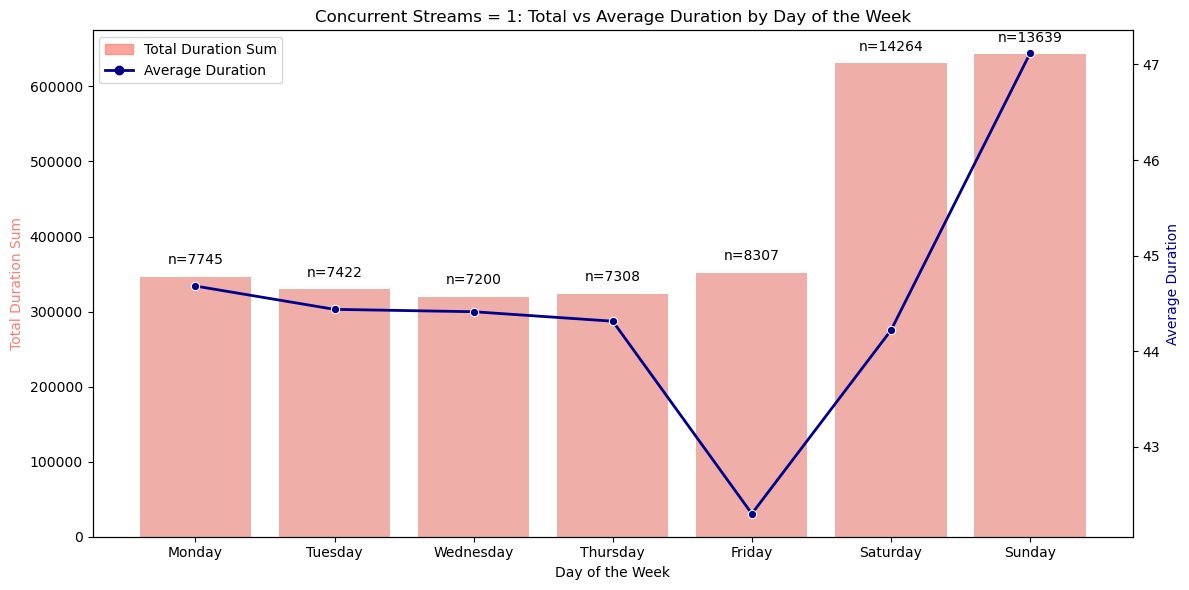

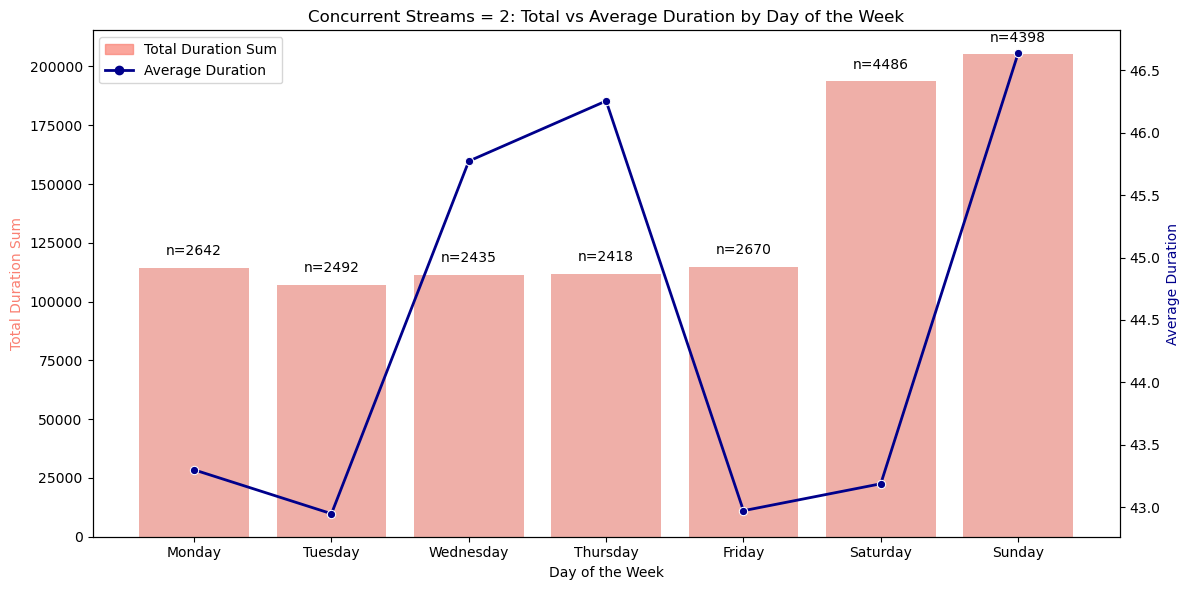

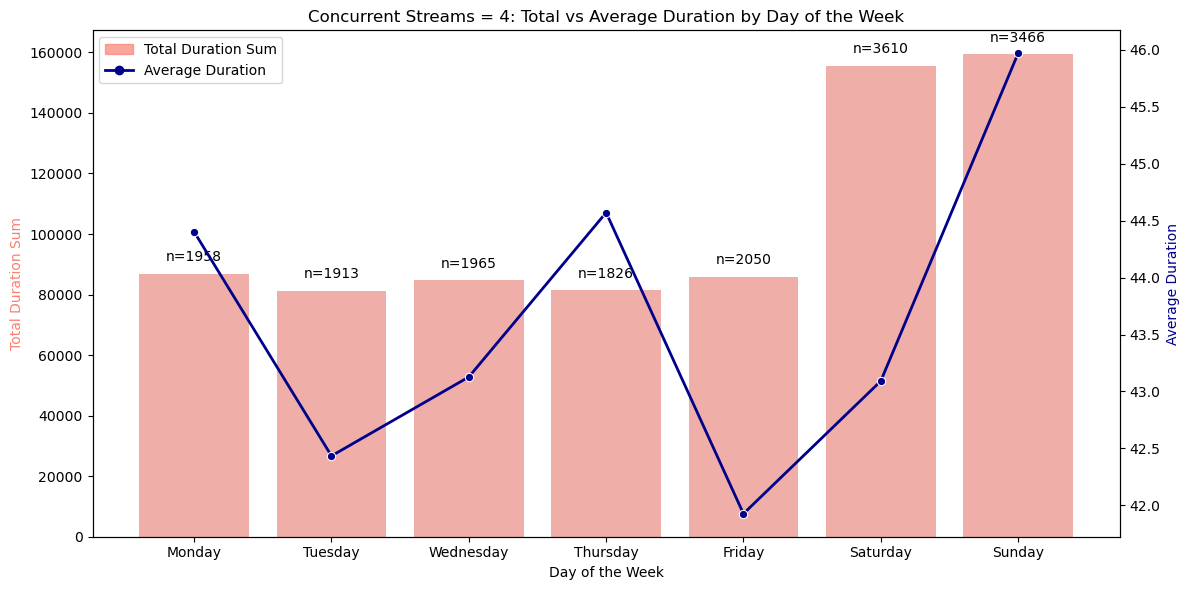

In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

# 파일 불러오기
file_path = r"C:\Users\user\Desktop\기업 연계 데이터\data merge\final_merged.csv"
df = pd.read_csv(file_path)

# 날짜형 변환
df["WATCH_DAY"] = pd.to_datetime(df["WATCH_DAY"].astype(str), format="%Y%m%d", errors="coerce")

# 수치형 변환
df["DURATION"] = pd.to_numeric(df["DURATION"], errors="coerce")
df["concurrent_streams"] = pd.to_numeric(df["concurrent_streams"], errors="coerce")

# 요일 컬럼 생성
df["day_of_week"] = df["WATCH_DAY"].dt.day_name()
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

# concurrent_streams별 그래프 생성
target_streams = [1, 2, 4]

for stream_value in target_streams:
    temp = df[df["concurrent_streams"] == stream_value].copy()

    # 요일별 Duration 집계
    dow_duration_stats = (
        temp.groupby("day_of_week")["DURATION"]
        .agg(total_duration="sum", avg_duration="mean", n="count")
        .reindex(day_order)
        .reset_index()
    )

    # 결측값 보정
    dow_duration_stats["total_duration"] = dow_duration_stats["total_duration"].fillna(0)
    dow_duration_stats["avg_duration"] = dow_duration_stats["avg_duration"].fillna(0)
    dow_duration_stats["n"] = dow_duration_stats["n"].fillna(0).astype(int)

    # 시각화
    fig, ax1 = plt.subplots(figsize=(12, 6))

    # 막대그래프 생성
    sns.barplot(
        data=dow_duration_stats,
        x="day_of_week",
        y="total_duration",
        ax=ax1,
        color="salmon",
        alpha=0.7
    )
    ax1.set_ylabel("Total Duration Sum", color="salmon")
    ax1.set_xlabel("Day of the Week")
    ax1.set_title(f"Concurrent Streams = {stream_value}: Total vs Average Duration by Day of the Week")

    # 막대 위 n 표시
    y_max = dow_duration_stats["total_duration"].max()

    for i, row in dow_duration_stats.iterrows():
        ax1.text(
            i,
            row["total_duration"] + (y_max * 0.02 if y_max > 0 else 1),
            f'n={row["n"]}',
            ha="center",
            va="bottom",
            fontsize=10,
            color="black"
        )

    # 선그래프 생성
    ax2 = ax1.twinx()
    sns.lineplot(
        data=dow_duration_stats,
        x=range(len(dow_duration_stats)),
        y="avg_duration",
        ax=ax2,
        color="darkblue",
        marker="o",
        linewidth=2
    )
    ax2.set_ylabel("Average Duration", color="darkblue")

    # 범례 생성
    legend_elements = [
        Patch(facecolor="salmon", edgecolor="salmon", alpha=0.7, label="Total Duration Sum"),
        Line2D([0], [0], color="darkblue", marker="o", linewidth=2, label="Average Duration")
    ]
    ax1.legend(handles=legend_elements, loc="upper left")

    plt.tight_layout()
    plt.show()


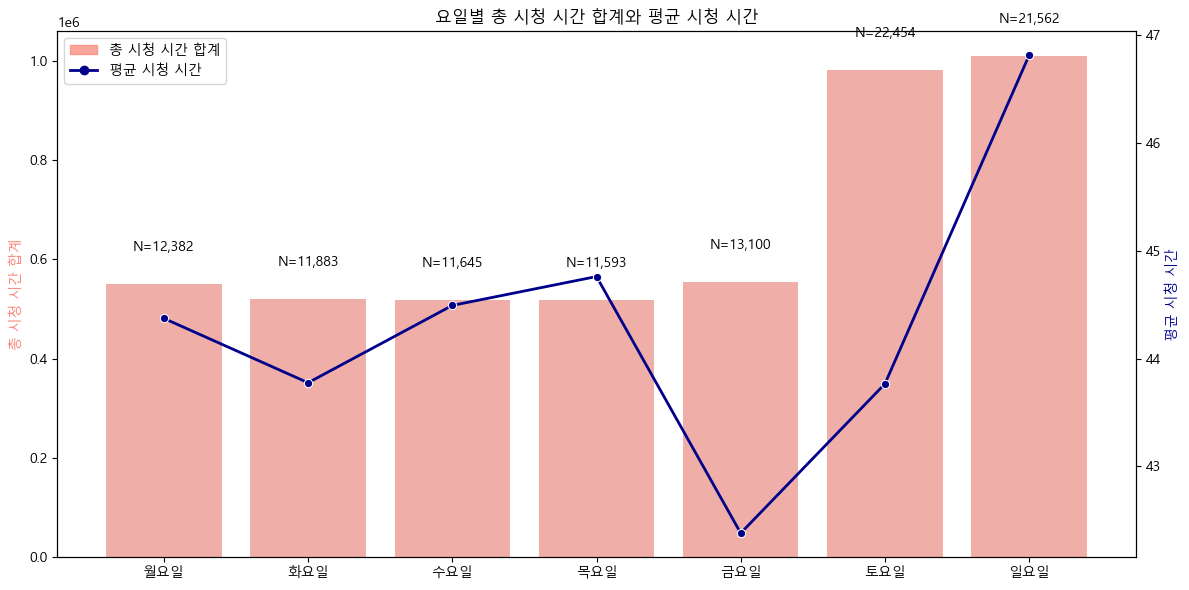

In [17]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

# 파일 불러오기
file_path = r"C:\Users\user\Desktop\기업 연계 데이터\data merge\final_merged.csv"
df = pd.read_csv(file_path)

# WATCH_DAY 날짜형 변환
df["WATCH_DAY"] = pd.to_datetime(
    df["WATCH_DAY"].astype(str),
    format="%Y%m%d",
    errors="coerce"
)

# DURATION 수치형 변환
df["DURATION"] = pd.to_numeric(df["DURATION"], errors="coerce")

# 분석용 결측치 제거
df = df.dropna(subset=["WATCH_DAY", "DURATION"]).copy()

# 한글 폰트 설정
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

# 요일 컬럼 생성
df["day_of_week"] = df["WATCH_DAY"].dt.day_name()

# 요일 순서 정의
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

# 요일명 한글 변환용 사전
day_name_map = {
    "Monday": "월요일",
    "Tuesday": "화요일",
    "Wednesday": "수요일",
    "Thursday": "목요일",
    "Friday": "금요일",
    "Saturday": "토요일",
    "Sunday": "일요일"
}

# 요일별 시청 시간 집계
dow_duration_stats = (
    df.groupby("day_of_week")
    .agg(
        total_duration=("DURATION", "sum"),
        avg_duration=("DURATION", "mean"),
        n=("DURATION", "count")
    )
    .reindex(day_order)
    .reset_index()
)

# 한글 요일 컬럼 생성
dow_duration_stats["요일"] = dow_duration_stats["day_of_week"].map(day_name_map)

# 시각화
fig, ax1 = plt.subplots(figsize=(12, 6))

# 막대그래프 생성
sns.barplot(
    data=dow_duration_stats,
    x="요일",
    y="total_duration",
    ax=ax1,
    color="salmon",
    alpha=0.7
)

ax1.set_ylabel("총 시청 시간 합계", color="salmon")
ax1.set_xlabel("")
ax1.set_title("요일별 총 시청 시간 합계와 평균 시청 시간")

# 선그래프 생성
ax2 = ax1.twinx()
sns.lineplot(
    data=dow_duration_stats,
    x=range(len(dow_duration_stats)),
    y="avg_duration",
    ax=ax2,
    color="darkblue",
    marker="o",
    linewidth=2
)

ax2.set_ylabel("평균 시청 시간", color="darkblue")
ax2.set_xticks(range(len(dow_duration_stats)))
ax2.set_xticklabels(dow_duration_stats["요일"])

# 막대 위 N 표시
y_max = dow_duration_stats["total_duration"].max()

for i, row in dow_duration_stats.iterrows():
    ax1.text(
        i,
        row["total_duration"] + (y_max * 0.06 if y_max > 0 else 1),
        f'N={int(row["n"]):,}',
        ha="center",
        va="bottom",
        fontsize=10,
        color="black"
    )

# 범례 생성
legend_elements = [
    Patch(facecolor="salmon", edgecolor="salmon", alpha=0.7, label="총 시청 시간 합계"),
    Line2D([0], [0], color="darkblue", marker="o", linewidth=2, label="평균 시청 시간")
]
ax1.legend(handles=legend_elements, loc="upper left")

plt.tight_layout()
plt.show()


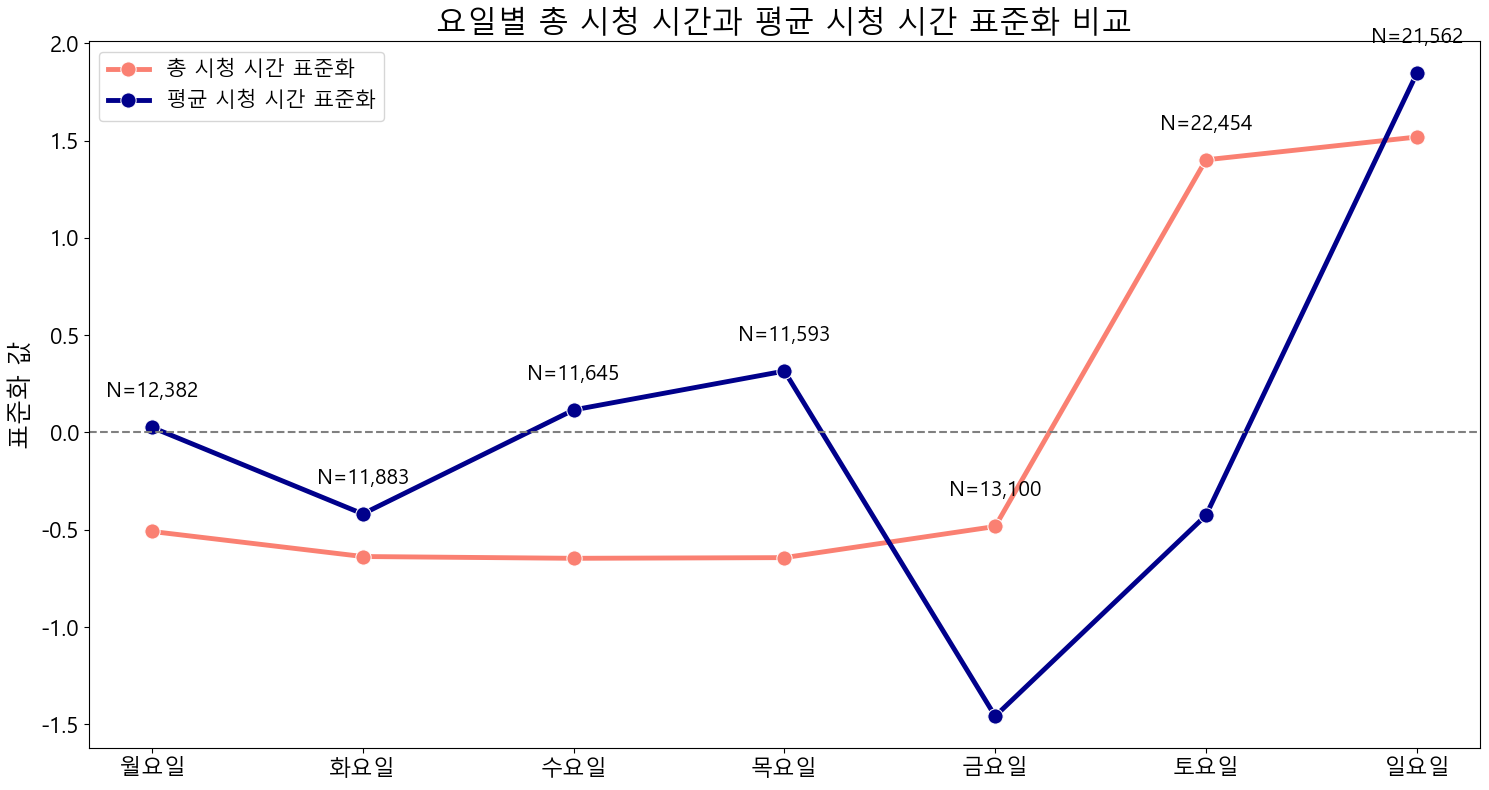

In [21]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 파일 불러오기
file_path = r"C:\Users\user\Desktop\기업 연계 데이터\data merge\final_merged.csv"
df = pd.read_csv(file_path)

# WATCH_DAY 날짜형 변환
df["WATCH_DAY"] = pd.to_datetime(
    df["WATCH_DAY"].astype(str),
    format="%Y%m%d",
    errors="coerce"
)

# DURATION 수치형 변환
df["DURATION"] = pd.to_numeric(df["DURATION"], errors="coerce")

# 분석용 결측치 제거
df = df.dropna(subset=["WATCH_DAY", "DURATION"]).copy()

# 한글 폰트 설정
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

# 요일 컬럼 생성
df["day_of_week"] = df["WATCH_DAY"].dt.day_name()
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

# 영문 요일을 한글 요일로 변환
day_name_map = {
    "Monday": "월요일",
    "Tuesday": "화요일",
    "Wednesday": "수요일",
    "Thursday": "목요일",
    "Friday": "금요일",
    "Saturday": "토요일",
    "Sunday": "일요일"
}

# 요일별 집계
dow_duration_stats = (
    df.groupby("day_of_week")
    .agg(
        total_duration=("DURATION", "sum"),
        avg_duration=("DURATION", "mean"),
        n=("DURATION", "count")
    )
    .reindex(day_order)
    .reset_index()
)

# 결측값 보정
dow_duration_stats["total_duration"] = dow_duration_stats["total_duration"].fillna(0)
dow_duration_stats["avg_duration"] = dow_duration_stats["avg_duration"].fillna(0)
dow_duration_stats["n"] = dow_duration_stats["n"].fillna(0).astype(int)

# 한글 요일 컬럼 생성
dow_duration_stats["요일"] = dow_duration_stats["day_of_week"].map(day_name_map)

# z-score 표준화 함수
def z_score(series):
    std = series.std()
    if std == 0:
        return pd.Series([0] * len(series), index=series.index)
    return (series - series.mean()) / std

# total_duration, avg_duration 표준화
dow_duration_stats["총_시청시간_표준화"] = z_score(dow_duration_stats["total_duration"])
dow_duration_stats["평균_시청시간_표준화"] = z_score(dow_duration_stats["avg_duration"])

# 시각화
plt.figure(figsize=(15, 8))

sns.lineplot(
    data=dow_duration_stats,
    x="요일",
    y="총_시청시간_표준화",
    marker="o",
    linewidth=3.5,
    markersize=11,
    color="salmon",
    label="총 시청 시간 표준화"
)

sns.lineplot(
    data=dow_duration_stats,
    x="요일",
    y="평균_시청시간_표준화",
    marker="o",
    linewidth=3.5,
    markersize=11,
    color="darkblue",
    label="평균 시청 시간 표준화"
)

# 각 점 위 N 표시
for i, row in dow_duration_stats.iterrows():
    top_value = max(row["총_시청시간_표준화"], row["평균_시청시간_표준화"])
    plt.text(
        i,
        top_value + 0.13,
        f'N={row["n"]:,}',
        ha="center",
        va="bottom",
        fontsize=15,
        color="black"
    )

# 기준선 추가
plt.axhline(0, color="gray", linestyle="--", linewidth=1.5)

# 축 및 제목 설정
plt.xlabel("")
plt.ylabel("표준화 값", fontsize=18)
plt.title("요일별 총 시청 시간과 평균 시청 시간 표준화 비교", fontsize=22)

# 축 눈금 글씨 크기 설정
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)

# 범례 글씨 크기 설정
plt.legend(fontsize=15)

plt.tight_layout()
plt.show()


### 고유 USER_ID 기준

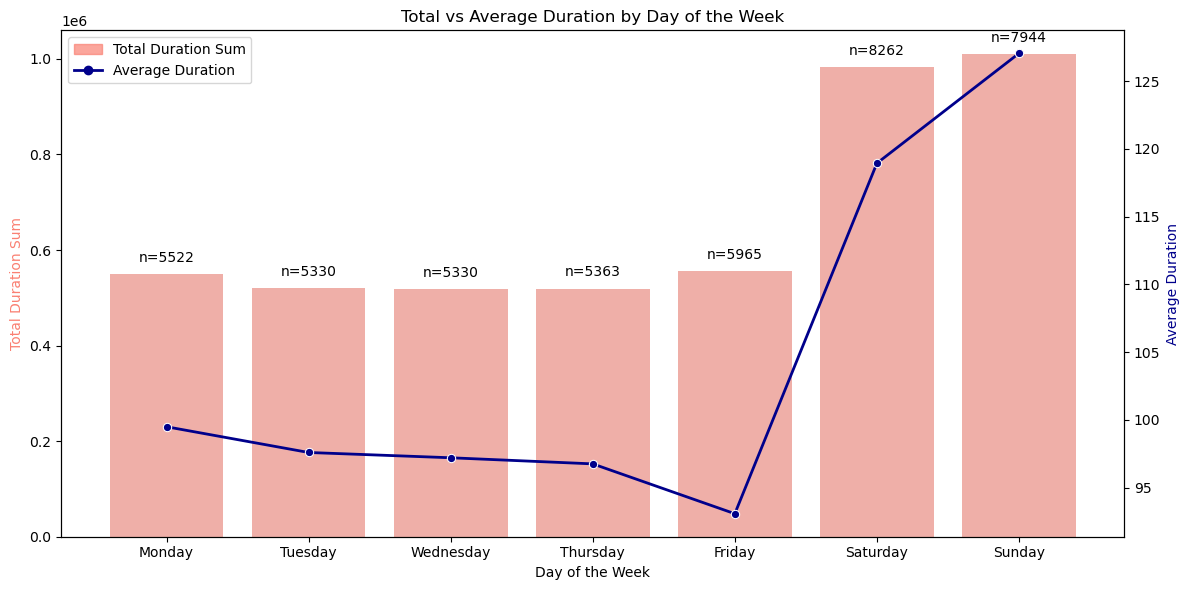

In [8]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

# 파일 불러오기
file_path = r"C:\Users\user\Desktop\기업 연계 데이터\data merge\final_merged.csv"
df = pd.read_csv(file_path)

# WATCH_DAY 날짜형 변환
df["WATCH_DAY"] = pd.to_datetime(df["WATCH_DAY"].astype(str), format="%Y%m%d", errors="coerce")

# DURATION 수치형 변환
df["DURATION"] = pd.to_numeric(df["DURATION"], errors="coerce")

# 결측치 제거
df = df.dropna(subset=["WATCH_DAY", "DURATION", "USER_ID"]).copy()

# 요일 컬럼 생성
df["day_of_week"] = df["WATCH_DAY"].dt.day_name()
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

# USER_ID + 요일 기준으로 먼저 DURATION 합산
user_day_duration = (
    df.groupby(["USER_ID", "day_of_week"], observed=False)["DURATION"]
    .sum()
    .reset_index()
)

# 요일별 집계
dow_duration_stats = (
    user_day_duration.groupby("day_of_week", observed=False)
    .agg(
        total_duration=("DURATION", "sum"),
        avg_duration=("DURATION", "mean"),
        n=("USER_ID", "count")
    )
    .reindex(day_order)
    .reset_index()
)

# 결측값 보정
dow_duration_stats["total_duration"] = dow_duration_stats["total_duration"].fillna(0)
dow_duration_stats["avg_duration"] = dow_duration_stats["avg_duration"].fillna(0)
dow_duration_stats["n"] = dow_duration_stats["n"].fillna(0).astype(int)

# 시각화
fig, ax1 = plt.subplots(figsize=(12, 6))

# 요일별 총 시청 시간 합계
sns.barplot(
    data=dow_duration_stats,
    x="day_of_week",
    y="total_duration",
    ax=ax1,
    color="salmon",
    alpha=0.7
)
ax1.set_ylabel("Total Duration Sum", color="salmon")
ax1.set_xlabel("Day of the Week")
ax1.set_title("Total vs Average Duration by Day of the Week")

# 막대 위 n 표시
y_max = dow_duration_stats["total_duration"].max()

for i, row in dow_duration_stats.iterrows():
    ax1.text(
        i,
        row["total_duration"] + (y_max * 0.02 if y_max > 0 else 1),
        f'n={row["n"]}',
        ha="center",
        va="bottom",
        fontsize=10,
        color="black"
    )

# 요일별 평균 시청 시간
ax2 = ax1.twinx()
sns.lineplot(
    data=dow_duration_stats,
    x=range(len(dow_duration_stats)),
    y="avg_duration",
    ax=ax2,
    color="darkblue",
    marker="o",
    linewidth=2
)
ax2.set_ylabel("Average Duration", color="darkblue")

# 범례 추가
legend_elements = [
    Patch(facecolor="salmon", edgecolor="salmon", alpha=0.7, label="Total Duration Sum"),
    Line2D([0], [0], color="darkblue", marker="o", linewidth=2, label="Average Duration")
]
ax1.legend(handles=legend_elements, loc="upper left")

plt.tight_layout()
plt.show()


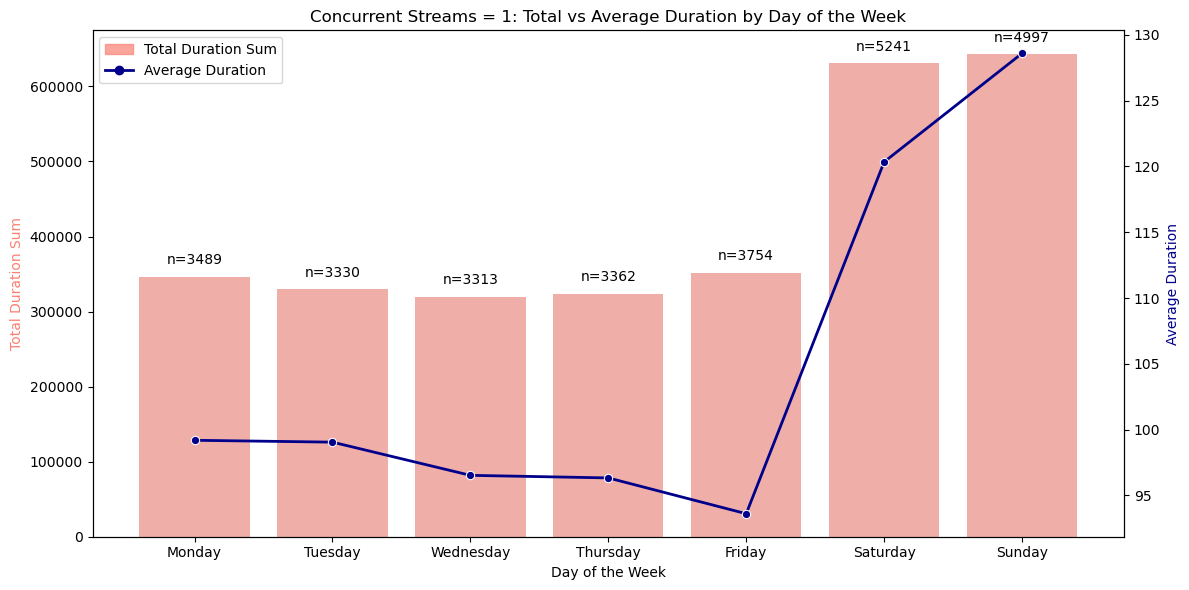

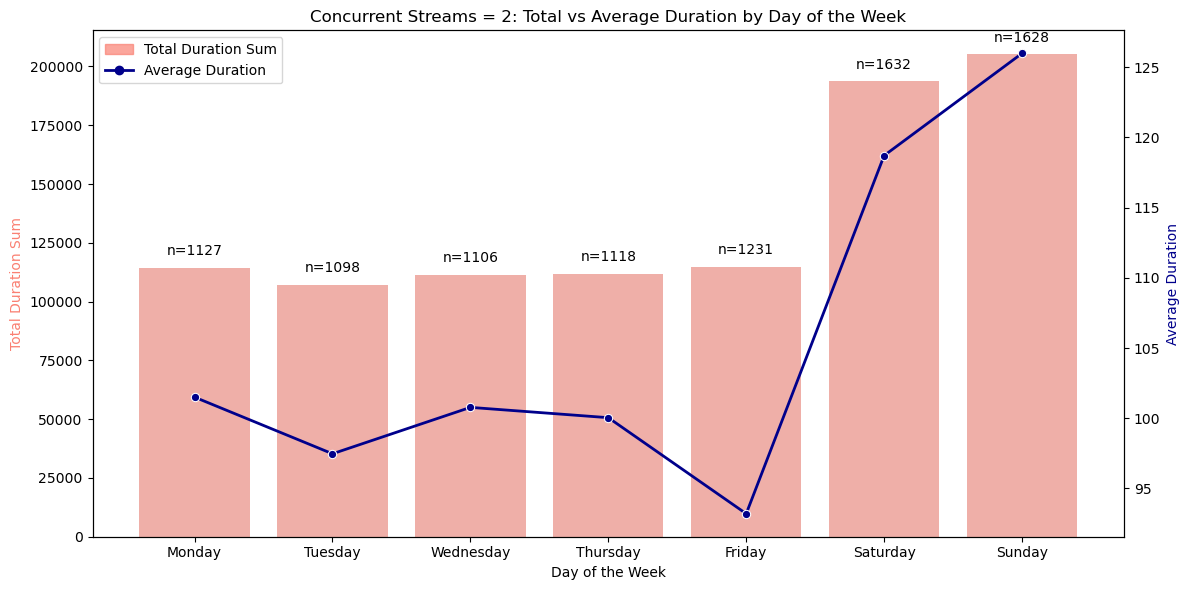

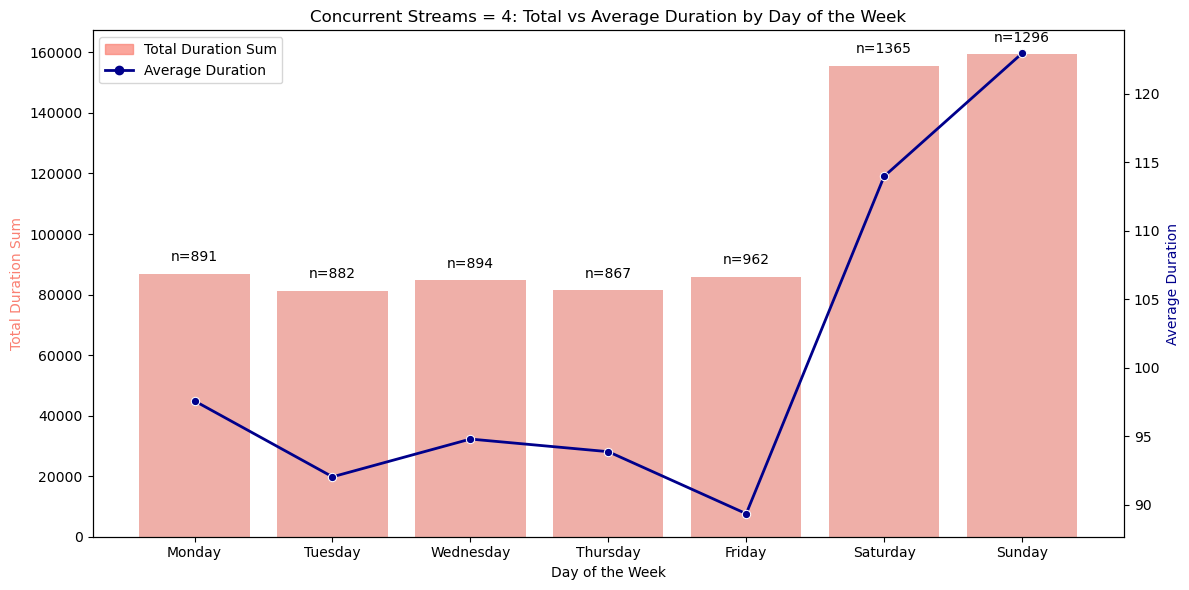

In [9]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

# 파일 불러오기
file_path = r"C:\Users\user\Desktop\기업 연계 데이터\data merge\final_merged.csv"
df = pd.read_csv(file_path)

# 날짜형 변환
df["WATCH_DAY"] = pd.to_datetime(
    df["WATCH_DAY"].astype(str),
    format="%Y%m%d",
    errors="coerce"
)

# 수치형 변환
df["DURATION"] = pd.to_numeric(df["DURATION"], errors="coerce")
df["concurrent_streams"] = pd.to_numeric(df["concurrent_streams"], errors="coerce")

# 분석용 결측치 제거
df = df.dropna(subset=["WATCH_DAY", "DURATION", "USER_ID", "concurrent_streams"]).copy()

# 요일 컬럼 생성
df["day_of_week"] = df["WATCH_DAY"].dt.day_name()
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

# concurrent_streams 대상값 설정
target_streams = [1, 2, 4]

for stream_value in target_streams:
    # concurrent_streams 필터링
    temp = df[df["concurrent_streams"] == stream_value].copy()

    # USER_ID + 요일 기준 duration 합산
    user_day_duration = (
        temp.groupby(["USER_ID", "day_of_week"], observed=False)["DURATION"]
        .sum()
        .reset_index()
    )

    # 요일별 집계
    dow_duration_stats = (
        user_day_duration.groupby("day_of_week", observed=False)
        .agg(
            total_duration=("DURATION", "sum"),
            avg_duration=("DURATION", "mean"),
            n=("USER_ID", "count")
        )
        .reindex(day_order)
        .reset_index()
    )

    # 결측값 보정
    dow_duration_stats["total_duration"] = dow_duration_stats["total_duration"].fillna(0)
    dow_duration_stats["avg_duration"] = dow_duration_stats["avg_duration"].fillna(0)
    dow_duration_stats["n"] = dow_duration_stats["n"].fillna(0).astype(int)

    # 시각화
    fig, ax1 = plt.subplots(figsize=(12, 6))

    # 총 시청 시간 합계 막대그래프
    sns.barplot(
        data=dow_duration_stats,
        x="day_of_week",
        y="total_duration",
        ax=ax1,
        color="salmon",
        alpha=0.7
    )
    ax1.set_ylabel("Total Duration Sum", color="salmon")
    ax1.set_xlabel("Day of the Week")
    ax1.set_title(
        f"Concurrent Streams = {stream_value}: Total vs Average Duration by Day of the Week"
    )

    # n 표시
    y_max = dow_duration_stats["total_duration"].max()

    for i, row in dow_duration_stats.iterrows():
        ax1.text(
            i,
            row["total_duration"] + (y_max * 0.02 if y_max > 0 else 1),
            f'n={row["n"]}',
            ha="center",
            va="bottom",
            fontsize=10,
            color="black"
        )

    # 평균 시청 시간 선그래프
    ax2 = ax1.twinx()
    sns.lineplot(
        data=dow_duration_stats,
        x=range(len(dow_duration_stats)),
        y="avg_duration",
        ax=ax2,
        color="darkblue",
        marker="o",
        linewidth=2
    )
    ax2.set_ylabel("Average Duration", color="darkblue")

    # 범례 추가
    legend_elements = [
        Patch(facecolor="salmon", edgecolor="salmon", alpha=0.7, label="Total Duration Sum"),
        Line2D([0], [0], color="darkblue", marker="o", linewidth=2, label="Average Duration")
    ]
    ax1.legend(handles=legend_elements, loc="upper left")

    plt.tight_layout()
    plt.show()


### 요일별 유저 수 대비 시청 기록

,day_of_week,row_count,unique_user_count,rows_per_user
0,Monday,12382,5522,2.24
1,Tuesday,11883,5330,2.23
2,Wednesday,11645,5330,2.18
3,Thursday,11593,5363,2.16
4,Friday,13100,5965,2.20
5,Saturday,22454,8262,2.72
6,Sunday,21562,7944,2.71


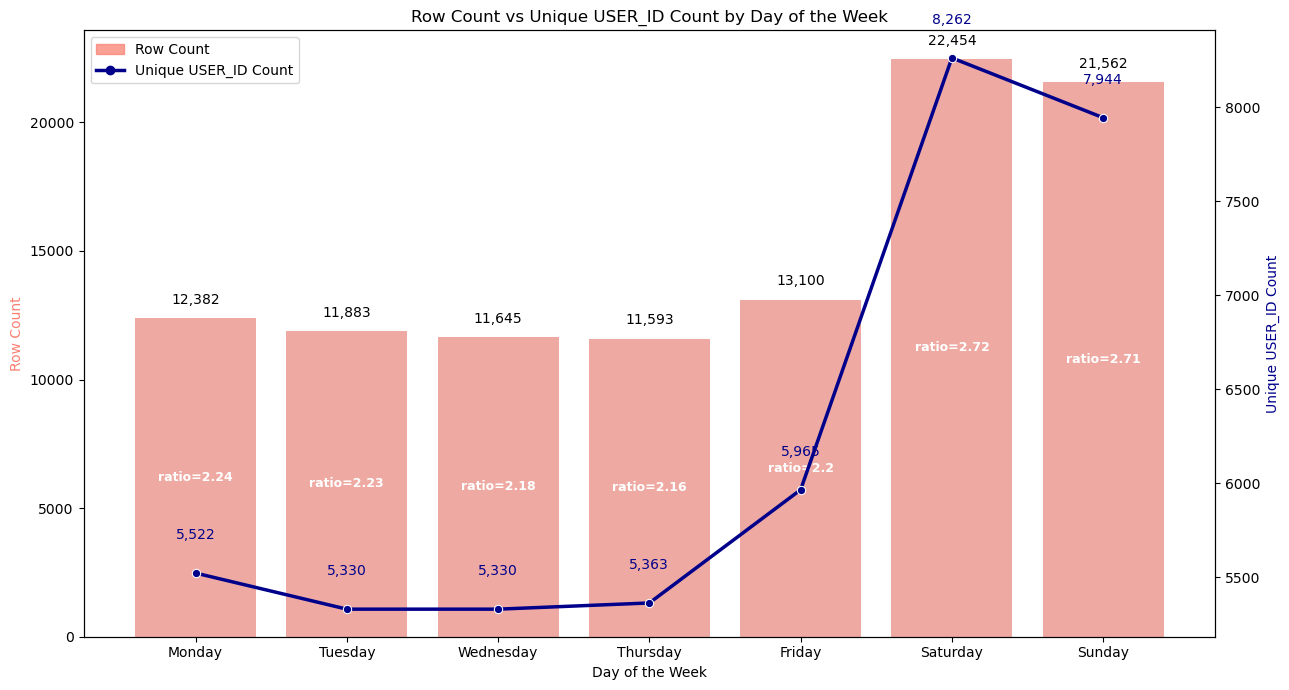

In [10]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

# 파일 불러오기
file_path = r"C:\Users\user\Desktop\기업 연계 데이터\data merge\final_merged.csv"
df = pd.read_csv(file_path)

# 날짜형 변환
df["WATCH_DAY"] = pd.to_datetime(
    df["WATCH_DAY"].astype(str),
    format="%Y%m%d",
    errors="coerce"
)

# 결측치 제거
df = df.dropna(subset=["WATCH_DAY", "USER_ID"]).copy()

# 요일 컬럼 생성
df["day_of_week"] = df["WATCH_DAY"].dt.day_name()
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

# 요일별 집계
dow_user_stats = (
    df.groupby("day_of_week")
    .agg(
        row_count=("USER_ID", "size"),
        unique_user_count=("USER_ID", "nunique")
    )
    .reindex(day_order)
    .reset_index()
)

# USER_ID 1명당 평균 행 수 계산
dow_user_stats["rows_per_user"] = (
    dow_user_stats["row_count"] / dow_user_stats["unique_user_count"]
)

# 결측값 보정
dow_user_stats["row_count"] = dow_user_stats["row_count"].fillna(0).astype(int)
dow_user_stats["unique_user_count"] = dow_user_stats["unique_user_count"].fillna(0).astype(int)
dow_user_stats["rows_per_user"] = dow_user_stats["rows_per_user"].fillna(0).round(2)

# 집계 결과 확인
display(dow_user_stats)

# 시각화
fig, ax1 = plt.subplots(figsize=(13, 7))

# 행 개수 막대그래프
sns.barplot(
    data=dow_user_stats,
    x="day_of_week",
    y="row_count",
    ax=ax1,
    color="salmon",
    alpha=0.75
)

ax1.set_xlabel("Day of the Week")
ax1.set_ylabel("Row Count", color="salmon")
ax1.set_title("Row Count vs Unique USER_ID Count by Day of the Week")

# 막대 위 행 개수 표시
row_max = dow_user_stats["row_count"].max()

for i, row in dow_user_stats.iterrows():
    ax1.text(
        i,
        row["row_count"] + (row_max * 0.02 if row_max > 0 else 1),
        f'{row["row_count"]:,}',
        ha="center",
        va="bottom",
        fontsize=10,
        color="black"
    )

# 고유 USER_ID 수 선그래프
ax2 = ax1.twinx()

sns.lineplot(
    data=dow_user_stats,
    x=range(len(dow_user_stats)),
    y="unique_user_count",
    ax=ax2,
    color="darkblue",
    marker="o",
    linewidth=2.5
)

ax2.set_ylabel("Unique USER_ID Count", color="darkblue")

# 선 위 고유 USER_ID 수 표시
user_max = dow_user_stats["unique_user_count"].max()

for i, row in dow_user_stats.iterrows():
    ax2.text(
        i,
        row["unique_user_count"] + (user_max * 0.02 if user_max > 0 else 1),
        f'{row["unique_user_count"]:,}',
        ha="center",
        va="bottom",
        fontsize=10,
        color="darkblue"
    )

# rows_per_user 값 표시
for i, row in dow_user_stats.iterrows():
    ax1.text(
        i,
        row["row_count"] * 0.5 if row["row_count"] > 0 else 1,
        f'ratio={row["rows_per_user"]}',
        ha="center",
        va="center",
        fontsize=9,
        color="white",
        fontweight="bold"
    )

# 범례 추가
legend_elements = [
    Patch(facecolor="salmon", edgecolor="salmon", alpha=0.75, label="Row Count"),
    Line2D([0], [0], color="darkblue", marker="o", linewidth=2.5, label="Unique USER_ID Count")
]
ax1.legend(handles=legend_elements, loc="upper left")

plt.tight_layout()
plt.show()


,day_of_week,row_count,unique_user_count,rows_per_user
0,Monday,7745,3489,2.22
1,Tuesday,7422,3330,2.23
2,Wednesday,7200,3313,2.17
3,Thursday,7308,3362,2.17
4,Friday,8307,3754,2.21
5,Saturday,14264,5241,2.72
6,Sunday,13639,4997,2.73


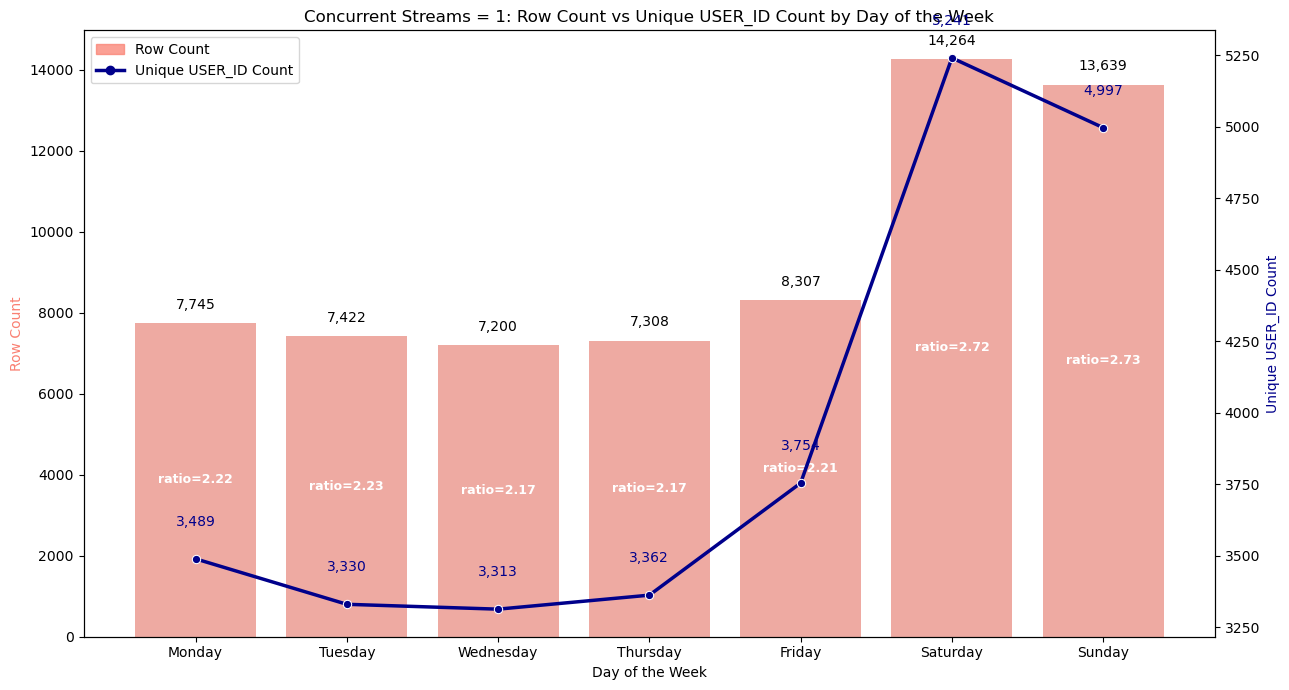

,day_of_week,row_count,unique_user_count,rows_per_user
0,Monday,2642,1127,2.34
1,Tuesday,2492,1098,2.27
2,Wednesday,2435,1106,2.20
3,Thursday,2418,1118,2.16
4,Friday,2670,1231,2.17
5,Saturday,4486,1632,2.75
6,Sunday,4398,1628,2.70


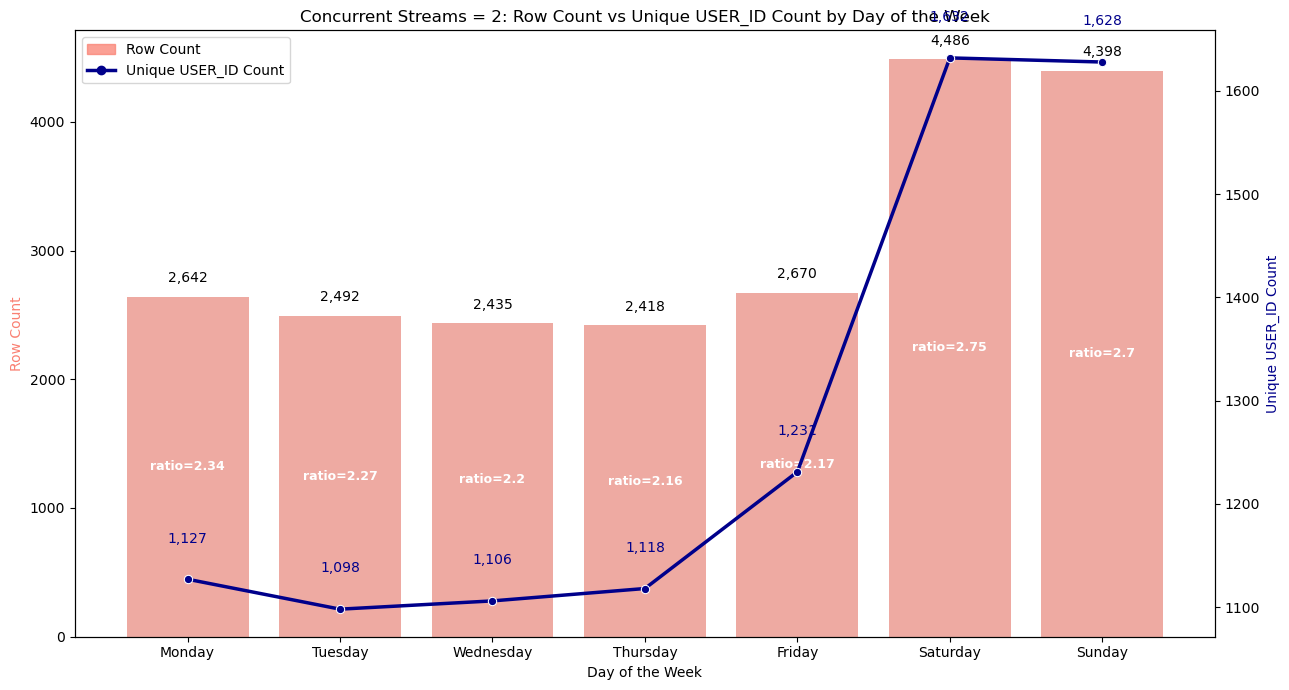

,day_of_week,row_count,unique_user_count,rows_per_user
0,Monday,1958,891,2.20
1,Tuesday,1913,882,2.17
2,Wednesday,1965,894,2.20
3,Thursday,1826,867,2.11
4,Friday,2050,962,2.13
5,Saturday,3610,1365,2.64
6,Sunday,3466,1296,2.67


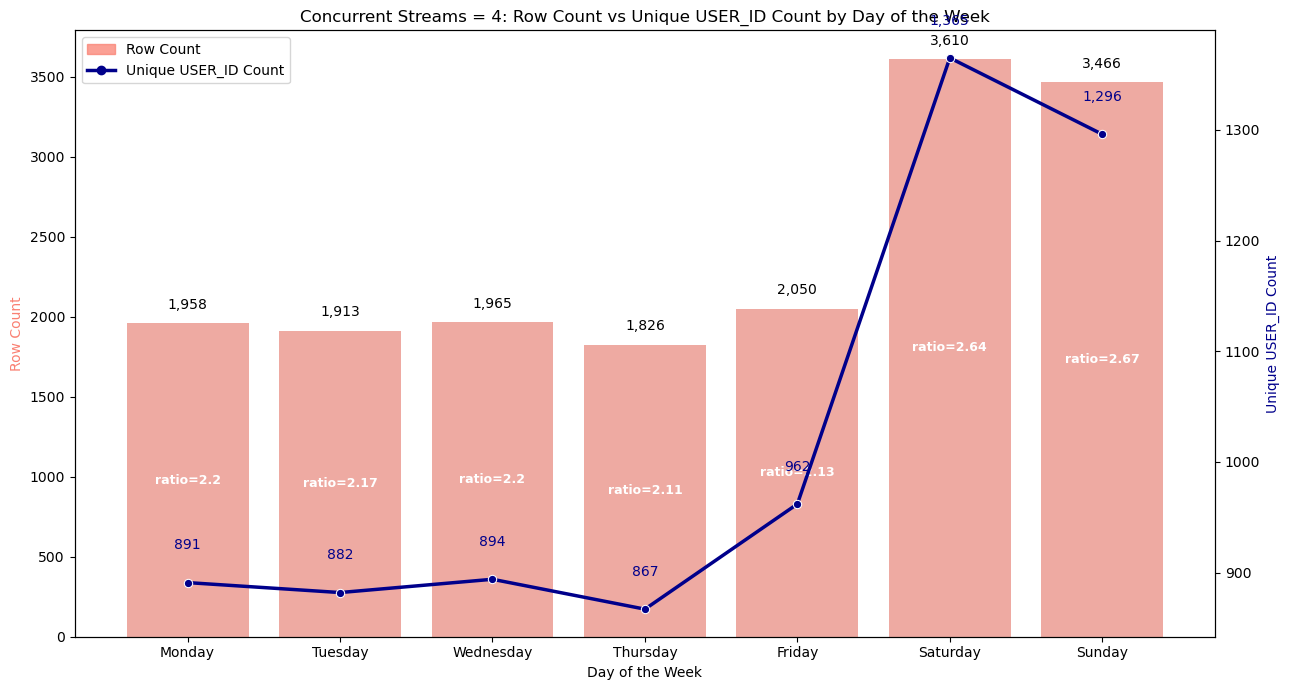

In [11]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

# 파일 불러오기
file_path = r"C:\Users\user\Desktop\기업 연계 데이터\data merge\final_merged.csv"
df = pd.read_csv(file_path)

# 날짜형 변환
df["WATCH_DAY"] = pd.to_datetime(
    df["WATCH_DAY"].astype(str),
    format="%Y%m%d",
    errors="coerce"
)

# 수치형 변환
df["concurrent_streams"] = pd.to_numeric(df["concurrent_streams"], errors="coerce")

# 결측치 제거
df = df.dropna(subset=["WATCH_DAY", "USER_ID", "concurrent_streams"]).copy()

# 요일 컬럼 생성
df["day_of_week"] = df["WATCH_DAY"].dt.day_name()
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

# 분석 대상 concurrent_streams 설정
target_streams = [1, 2, 4]

for stream_value in target_streams:
    # concurrent_streams 필터링
    temp = df[df["concurrent_streams"] == stream_value].copy()

    # 요일별 집계
    dow_user_stats = (
        temp.groupby("day_of_week")
        .agg(
            row_count=("USER_ID", "size"),
            unique_user_count=("USER_ID", "nunique")
        )
        .reindex(day_order)
        .reset_index()
    )

    # 사용자 1명당 평균 행 수 계산
    dow_user_stats["rows_per_user"] = (
        dow_user_stats["row_count"] / dow_user_stats["unique_user_count"]
    )

    # 결측값 보정
    dow_user_stats["row_count"] = dow_user_stats["row_count"].fillna(0).astype(int)
    dow_user_stats["unique_user_count"] = dow_user_stats["unique_user_count"].fillna(0).astype(int)
    dow_user_stats["rows_per_user"] = dow_user_stats["rows_per_user"].fillna(0).round(2)

    # 결과 확인
    display(dow_user_stats)

    # 시각화
    fig, ax1 = plt.subplots(figsize=(13, 7))

    # 행 개수 막대그래프
    sns.barplot(
        data=dow_user_stats,
        x="day_of_week",
        y="row_count",
        ax=ax1,
        color="salmon",
        alpha=0.75
    )

    ax1.set_xlabel("Day of the Week")
    ax1.set_ylabel("Row Count", color="salmon")
    ax1.set_title(f"Concurrent Streams = {stream_value}: Row Count vs Unique USER_ID Count by Day of the Week")

    # 막대 위 행 개수 표시
    row_max = dow_user_stats["row_count"].max()

    for i, row in dow_user_stats.iterrows():
        ax1.text(
            i,
            row["row_count"] + (row_max * 0.02 if row_max > 0 else 1),
            f'{row["row_count"]:,}',
            ha="center",
            va="bottom",
            fontsize=10,
            color="black"
        )

    # 고유 USER_ID 수 선그래프
    ax2 = ax1.twinx()

    sns.lineplot(
        data=dow_user_stats,
        x=range(len(dow_user_stats)),
        y="unique_user_count",
        ax=ax2,
        color="darkblue",
        marker="o",
        linewidth=2.5
    )

    ax2.set_ylabel("Unique USER_ID Count", color="darkblue")

    # 선 위 고유 USER_ID 수 표시
    user_max = dow_user_stats["unique_user_count"].max()

    for i, row in dow_user_stats.iterrows():
        ax2.text(
            i,
            row["unique_user_count"] + (user_max * 0.02 if user_max > 0 else 1),
            f'{row["unique_user_count"]:,}',
            ha="center",
            va="bottom",
            fontsize=10,
            color="darkblue"
        )

    # 막대 안 rows_per_user 표시
    for i, row in dow_user_stats.iterrows():
        ax1.text(
            i,
            row["row_count"] * 0.5 if row["row_count"] > 0 else 1,
            f'ratio={row["rows_per_user"]}',
            ha="center",
            va="center",
            fontsize=9,
            color="white",
            fontweight="bold"
        )

    # 범례 추가
    legend_elements = [
        Patch(facecolor="salmon", edgecolor="salmon", alpha=0.75, label="Row Count"),
        Line2D([0], [0], color="darkblue", marker="o", linewidth=2.5, label="Unique USER_ID Count")
    ]
    ax1.legend(handles=legend_elements, loc="upper left")

    plt.tight_layout()
    plt.show()


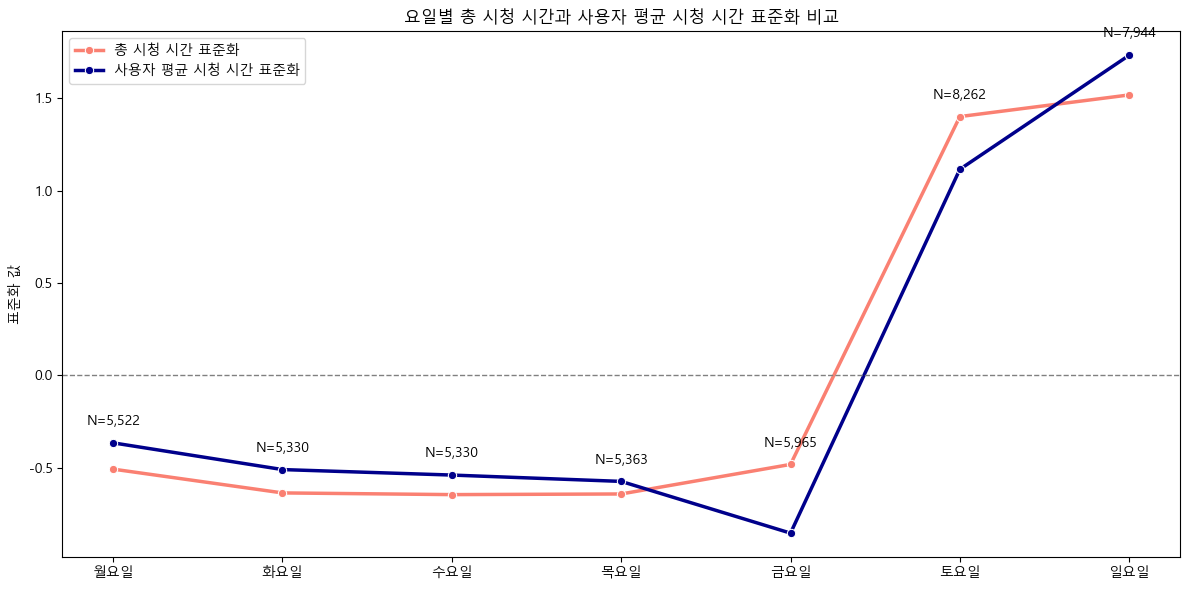

In [19]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 파일 불러오기
file_path = r"C:\Users\user\Desktop\기업 연계 데이터\data merge\final_merged.csv"
df = pd.read_csv(file_path)

# WATCH_DAY 날짜형 변환
df["WATCH_DAY"] = pd.to_datetime(
    df["WATCH_DAY"].astype(str),
    format="%Y%m%d",
    errors="coerce"
)

# DURATION 수치형 변환
df["DURATION"] = pd.to_numeric(df["DURATION"], errors="coerce")

# 분석용 결측치 제거
df = df.dropna(subset=["WATCH_DAY", "DURATION", "USER_ID"]).copy()

# 한글 폰트 설정
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

# 요일 컬럼 생성
df["day_of_week"] = df["WATCH_DAY"].dt.day_name()
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

# 영문 요일-한글 요일 매핑
day_name_map = {
    "Monday": "월요일",
    "Tuesday": "화요일",
    "Wednesday": "수요일",
    "Thursday": "목요일",
    "Friday": "금요일",
    "Saturday": "토요일",
    "Sunday": "일요일"
}

# USER_ID + 요일 기준 시청 시간 합산
user_day_duration = (
    df.groupby(["USER_ID", "day_of_week"], observed=False)
    .agg(
        user_duration=("DURATION", "sum")
    )
    .reset_index()
)

# 요일별 집계
dow_user_duration_stats = (
    user_day_duration.groupby("day_of_week", observed=False)
    .agg(
        total_duration=("user_duration", "sum"),
        avg_duration=("user_duration", "mean"),
        n=("USER_ID", "nunique")
    )
    .reindex(day_order)
    .reset_index()
)

# 결측값 보정
dow_user_duration_stats["total_duration"] = dow_user_duration_stats["total_duration"].fillna(0)
dow_user_duration_stats["avg_duration"] = dow_user_duration_stats["avg_duration"].fillna(0)
dow_user_duration_stats["n"] = dow_user_duration_stats["n"].fillna(0).astype(int)

# 한글 요일 컬럼 생성
dow_user_duration_stats["요일"] = dow_user_duration_stats["day_of_week"].map(day_name_map)

# z-score 표준화 함수
def z_score(series):
    std = series.std()
    if std == 0:
        return pd.Series([0] * len(series), index=series.index)
    return (series - series.mean()) / std

# 표준화 컬럼 생성
dow_user_duration_stats["총_시청시간_표준화"] = z_score(dow_user_duration_stats["total_duration"])
dow_user_duration_stats["사용자평균_시청시간_표준화"] = z_score(dow_user_duration_stats["avg_duration"])

# 시각화
plt.figure(figsize=(12, 6))

sns.lineplot(
    data=dow_user_duration_stats,
    x="요일",
    y="총_시청시간_표준화",
    marker="o",
    linewidth=2.5,
    color="salmon",
    label="총 시청 시간 표준화"
)

sns.lineplot(
    data=dow_user_duration_stats,
    x="요일",
    y="사용자평균_시청시간_표준화",
    marker="o",
    linewidth=2.5,
    color="darkblue",
    label="사용자 평균 시청 시간 표준화"
)

# 각 요일별 N 표시
for i, row in dow_user_duration_stats.iterrows():
    top_value = max(row["총_시청시간_표준화"], row["사용자평균_시청시간_표준화"])
    plt.text(
        i,
        top_value + 0.08,
        f'N={row["n"]:,}',
        ha="center",
        va="bottom",
        fontsize=10,
        color="black"
    )

# 기준선 추가
plt.axhline(0, color="gray", linestyle="--", linewidth=1)

# 축 및 제목 설정
plt.xlabel("")
plt.ylabel("표준화 값")
plt.title("요일별 총 시청 시간과 사용자 평균 시청 시간 표준화 비교")

plt.legend()
plt.tight_layout()
plt.show()


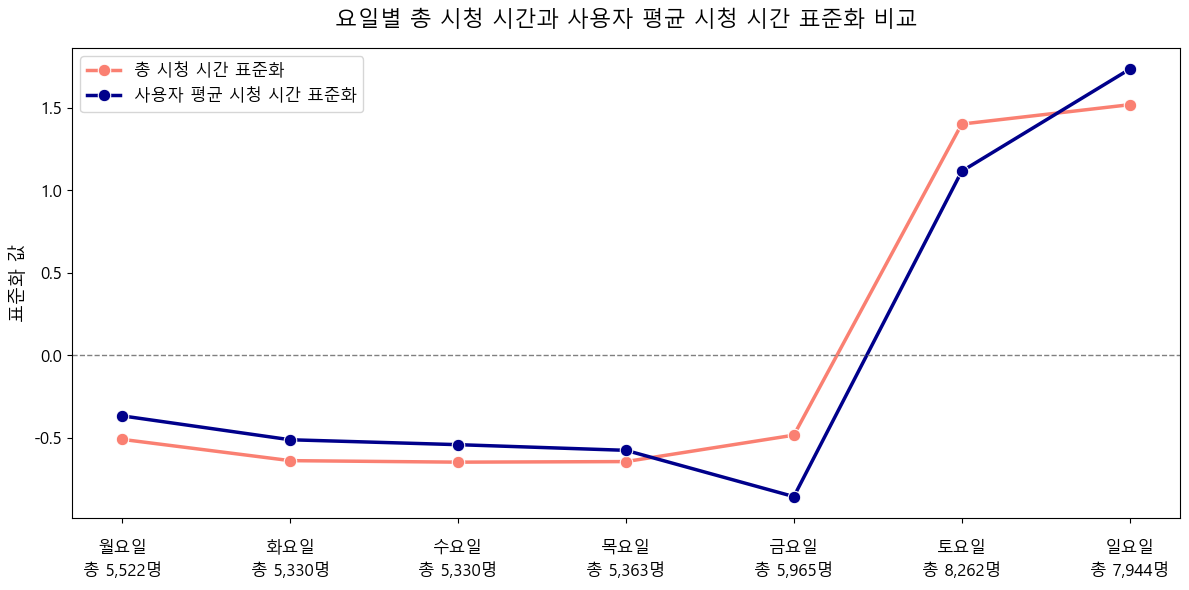

In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 파일 불러오기
file_path = r"C:\Users\user\Desktop\기업 연계 데이터\data merge\final_merged.csv"
df = pd.read_csv(file_path)

# WATCH_DAY 날짜형 변환
df["WATCH_DAY"] = pd.to_datetime(
    df["WATCH_DAY"].astype(str),
    format="%Y%m%d",
    errors="coerce"
)

# DURATION 수치형 변환
df["DURATION"] = pd.to_numeric(df["DURATION"], errors="coerce")

# 분석용 결측치 제거
df = df.dropna(subset=["WATCH_DAY", "DURATION", "USER_ID"]).copy()

# 한글 폰트 설정
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

# 요일 컬럼 생성
df["day_of_week"] = df["WATCH_DAY"].dt.day_name()
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

# 영문 요일-한글 요일 매핑
day_name_map = {
    "Monday": "월요일",
    "Tuesday": "화요일",
    "Wednesday": "수요일",
    "Thursday": "목요일",
    "Friday": "금요일",
    "Saturday": "토요일",
    "Sunday": "일요일"
}

# USER_ID + 요일 기준 시청 시간 합산
user_day_duration = (
    df.groupby(["USER_ID", "day_of_week"], observed=False)
    .agg(
        user_duration=("DURATION", "sum")
    )
    .reset_index()
)

# 요일별 집계
dow_user_duration_stats = (
    user_day_duration.groupby("day_of_week", observed=False)
    .agg(
        total_duration=("user_duration", "sum"),
        avg_duration=("user_duration", "mean"),
        n=("USER_ID", "nunique")
    )
    .reindex(day_order)
    .reset_index()
)

# 결측값 보정
dow_user_duration_stats["total_duration"] = dow_user_duration_stats["total_duration"].fillna(0)
dow_user_duration_stats["avg_duration"] = dow_user_duration_stats["avg_duration"].fillna(0)
dow_user_duration_stats["n"] = dow_user_duration_stats["n"].fillna(0).astype(int)

# 한글 요일 컬럼 생성
dow_user_duration_stats["요일"] = dow_user_duration_stats["day_of_week"].map(day_name_map)

# x축 표시용 라벨 생성
dow_user_duration_stats["요일_표시"] = (
    dow_user_duration_stats["요일"]
    + "\n"
    + dow_user_duration_stats["n"].map(lambda x: f"총 {x:,}명")
)

# z-score 표준화 함수 정의
def z_score(series):
    std = series.std()
    if std == 0:
        return pd.Series([0] * len(series), index=series.index)
    return (series - series.mean()) / std

# 표준화 컬럼 생성
dow_user_duration_stats["총_시청시간_표준화"] = z_score(dow_user_duration_stats["total_duration"])
dow_user_duration_stats["사용자평균_시청시간_표준화"] = z_score(dow_user_duration_stats["avg_duration"])

# 시각화
fig, ax = plt.subplots(figsize=(12, 6))

sns.lineplot(
    data=dow_user_duration_stats,
    x="요일",
    y="총_시청시간_표준화",
    marker="o",
    linewidth=2.5,
    markersize=9,
    color="salmon",
    label="총 시청 시간 표준화",
    ax=ax
)

sns.lineplot(
    data=dow_user_duration_stats,
    x="요일",
    y="사용자평균_시청시간_표준화",
    marker="o",
    linewidth=2.5,
    markersize=9,
    color="darkblue",
    label="사용자 평균 시청 시간 표준화",
    ax=ax
)

# x축 라벨 설정
ax.set_xticks(range(len(dow_user_duration_stats)))
ax.set_xticklabels(
    dow_user_duration_stats["요일_표시"],
    fontsize=12,
    linespacing=1.5
)
ax.tick_params(axis="x", pad=12)

# y축 눈금 글씨 크기 설정
ax.tick_params(axis="y", labelsize=12)

# 기준선 추가
ax.axhline(0, color="gray", linestyle="--", linewidth=1)

# 축 및 제목 설정
ax.set_xlabel("")
ax.set_ylabel("표준화 값", fontsize=13)
ax.set_title("요일별 총 시청 시간과 사용자 평균 시청 시간 표준화 비교", fontsize=16, pad=15)

# 범례 설정
ax.legend(fontsize=12, title_fontsize=13)

plt.tight_layout()
plt.show()


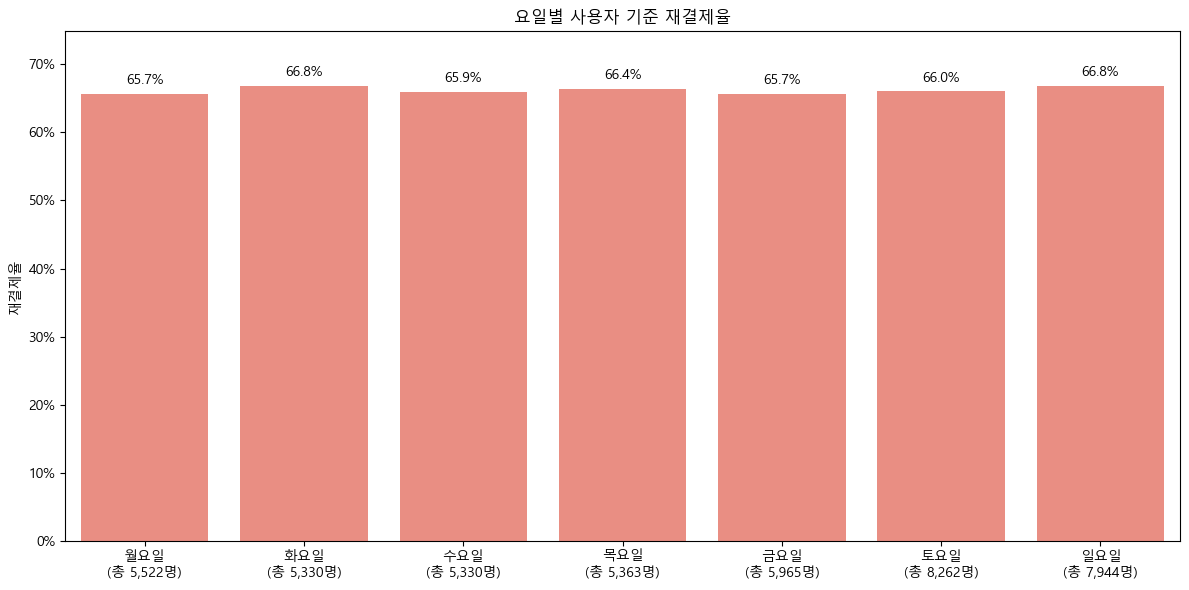